# Implementación de un flujo completo de deeep learning de principio a fin

In [4]:
pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\cmedi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
pip install torchvision

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------- ----------------------------- 1.0/4.0 MB 4.6 MB/s eta 0:00:01
   ------------------ --------------------- 1.8/4.0 MB 4.4 MB/s eta 0:00:01
   -------------------------- ------------- 2.6/4.0 MB 3.8 MB/s eta 0:00:01
   --------------------------------- ------ 3.4/4.0 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 3.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\cmedi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [25]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 882.6 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.2 MB 1.3 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.2 MB 1.5 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.2 MB 1.6 MB/s eta 0:00:05
   -------- ------------------------------- 1.8/8.2 MB 1.5 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.2 MB 1.4 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.2 MB 1.5 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.2 MB 1.5 MB/s eta 0:00:04
   --------------- ------------------------ 3.1/8.2 MB 1.5 MB/s eta 0:00:04
   ---------------- ---------


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\cmedi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [29]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 419.4 kB/s eta 0:00:23
   -- ------------------------------------- 0.5/9.8 MB 419.4 kB/s eta 0:00:23
   -- ------------------------------------- 0.5/9.8 MB 419.4 kB/s eta 0:00:23
   -- ------------------------------------- 0.5/9.8 MB 419.4 kB/s eta 0:00:23
   -- ------------------------------------- 0.5/9.8 MB 419.4 kB/s eta 0:00:23
   -- ------------------------------------- 0.5/9.8 MB 419.4 kB/s et


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\cmedi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [35]:
import random
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch.utils.data import random_split, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from torchvision import models


## Cargado de los datasets
- Definición de la transformación que va a cambiar cada uno de las imágenes de los dos datasets en un tensor y las va a normalizar para que tengan un valor entre [-1, 1]
- Cargado del dataset MNIST de entrenamiento
- Cargado del dataser MNIST de pruebas

In [12]:
transform = transforms.Compose([
 transforms.ToTensor(),
 transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

print("Tamaño del set de entrenamiento:", len(train_data))
print("Tamaño del set de prueba:", len(test_data))

Tamaño del set de entrenamiento: 60000
Tamaño del set de prueba: 10000


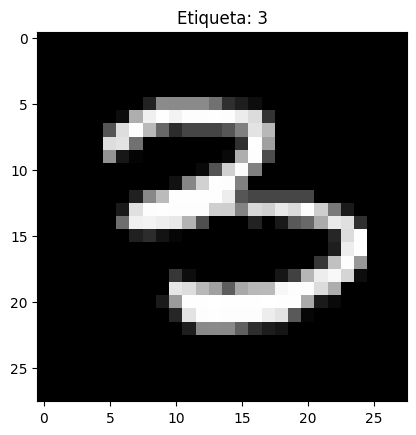

In [17]:
image, label = train_data[random.randint(0, 59999)]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Etiqueta: {label}")
plt.show()

## Creación de los datasets

Se dividen los datos de entrenamiento para dejar un 20% de validación. 
Se generan batches aleatorios de 64 imagenes por batch para ser cargados al modelo

In [18]:
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

batch_size = 64

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)


## Definición del modelo

In [19]:
model = nn.Sequential(
 nn.Flatten(),
 nn.Linear(28*28, 128),
 nn.ReLU(),
 nn.Dropout(0.2),
 nn.Linear(128, 64),
 nn.ReLU(),
 nn.Linear(64, 10)
)

## Función de pérdida y optimizador

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Entrenamiento del modelo

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 10

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            val_loss += criterion(
                outputs,
                labels
            ).item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (
                predicted == labels
            ).sum().item()

    accuracy = correct / total
    val_losses.append(
        val_loss / len(val_loader)
    )
    val_accuracies.append(
        accuracy
    )
    print(
        f"Epoch {epoch+1} | "
        f"Train Loss={train_loss:.4f} | "
        f"Val Acc={accuracy:.4f}"
    )

Epoch 1 | Train Loss=0.4877 | Val Acc=0.9104
Epoch 2 | Train Loss=0.2531 | Val Acc=0.9387
Epoch 3 | Train Loss=0.2021 | Val Acc=0.9523
Epoch 4 | Train Loss=0.1701 | Val Acc=0.9554
Epoch 5 | Train Loss=0.1575 | Val Acc=0.9608
Epoch 6 | Train Loss=0.1495 | Val Acc=0.9630
Epoch 7 | Train Loss=0.1341 | Val Acc=0.9650
Epoch 8 | Train Loss=0.1283 | Val Acc=0.9661
Epoch 9 | Train Loss=0.1189 | Val Acc=0.9621
Epoch 10 | Train Loss=0.1152 | Val Acc=0.9647


## Curvas de perdida

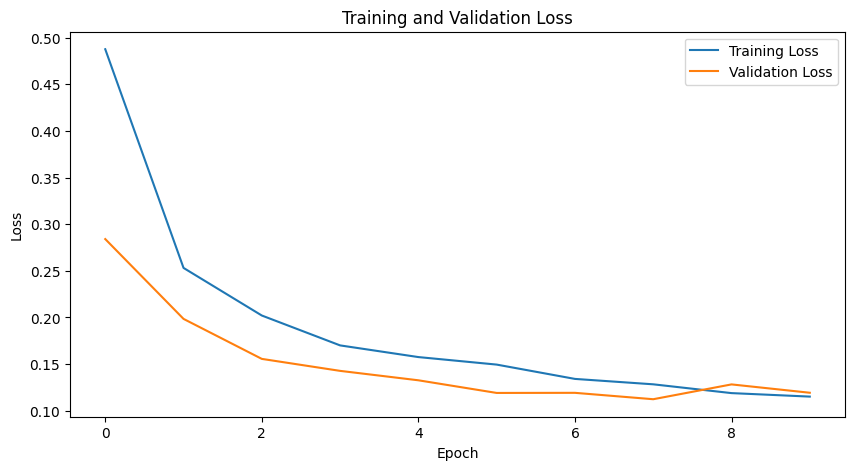

In [33]:
plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.savefig(
    "../media/training_curves.png"
)

plt.show()

## Curva de accuracy

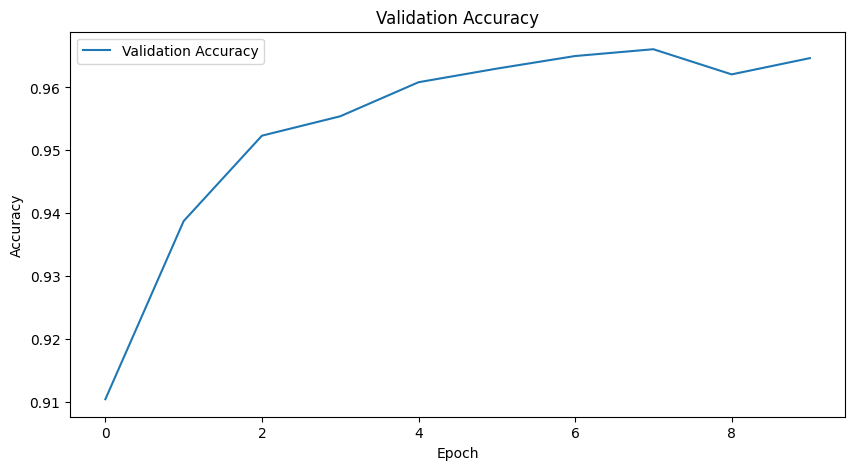

In [34]:
plt.figure(figsize=(10,5))

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.savefig(
    "../media/validation_accuracy.png"
)

plt.show()

## K-Fold

In [27]:
kf = KFold(n_splits=5)
X = torch.stack([train_data[i][0] for i in range(len(train_data))])
y = torch.tensor([train_data[i][1] for i in range(len(train_data))])

## Validación con test loader

In [31]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        output = model(images)
        _, preds = torch.max(output, 1)
        all_preds.extend(preds.cpu())
        all_labels.extend(labels)

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.97      1.00      0.98      1135
           2       0.97      0.97      0.97      1032
           3       0.98      0.95      0.97      1010
           4       0.95      0.98      0.97       982
           5       0.97      0.94      0.96       892
           6       0.97      0.96      0.97       958
           7       0.96      0.96      0.96      1028
           8       0.96      0.95      0.96       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.96      0.97     10000
weighted avg       0.97      0.97      0.97     10000



<Axes: >

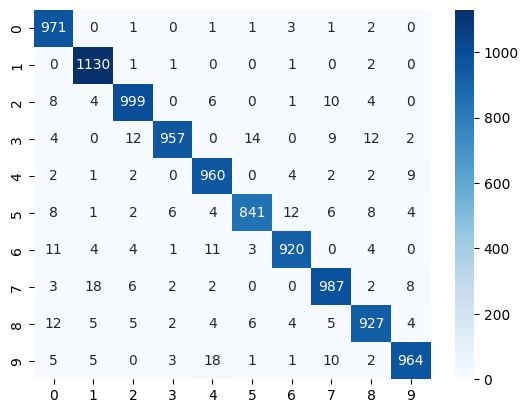

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

## Fine tuning

In [36]:
model_ft = models.resnet18(pretrained=True)

# Congelar todas las capas
for param in model_ft.parameters():
    param.requires_grad = False

# Reemplazar capa final
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 10) # 10 clases

model_ft.to(device)


C:\Users\cmedi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\cmedi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\cmedi/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [ ]:
optimizer = optim.Adam(model_ft.fc.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()



In [38]:
transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

In [39]:
train_data_resnet = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform_resnet
)

test_data_resnet = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform_resnet
)

In [40]:
train_size = int(0.8 * len(train_data_resnet))
val_size = len(train_data_resnet) - train_size

train_subset_resnet, val_subset_resnet = random_split(
    train_data_resnet,
    [train_size, val_size]
)

In [41]:
train_loader_resnet = DataLoader(
    train_subset_resnet,
    batch_size=64,
    shuffle=True
)

val_loader_resnet = DataLoader(
    val_subset_resnet,
    batch_size=64
)

test_loader_resnet = DataLoader(
    test_data_resnet,
    batch_size=64
)

In [ ]:
for epoch in range(epochs):

    model_ft.train()

    for images, labels in train_loader_resnet:

        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model_ft(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

In [ ]:
model_ft.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader_resnet:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_ft(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy_resnet = correct / total

print(f"Accuracy ResNet18: {accuracy_resnet:.4f}")

In [ ]:
# torch.save(model.state_dict(), "modelo_final.pth")
